# 02 — Exploratory Data Analysis

Which customer and campaign characteristics are associated with a higher chance of subscribing —
using only information available *before* the customer is contacted? `duration` is excluded
throughout, consistent with notebook 01's leakage finding.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root != project_root.parent:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loader import load_bank_data
from src.eda_analysis import build_segment_summary, generate_eda_figures
from src.config import PDAYS_NEVER_CONTACTED

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

raw_df = load_bank_data()
print('Shape:', raw_df.shape)
summary = build_segment_summary(raw_df)
print('Overall subscription rate:', round(summary['target_share']['yes'], 4))

Shape: (41188, 21)
Overall subscription rate: 0.1127


## Prior-contact history: the strongest signal in the data

In [2]:
print(summary['response_by_prior_contact'])

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(summary['response_by_prior_contact'].keys(), summary['response_by_prior_contact'].values(),
       color=['steelblue', 'darkorange'])
ax.set_ylabel('Subscription rate')
ax.set_title('Response rate: contacted before vs. first contact')
plt.show()

{'first_contact': 0.09258185667834548, 'contacted_before': 0.6382838283828383}


/var/folders/97/d0q84ynd0k5b2p19rklm8_800000gn/T/ipykernel_77410/2129777553.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Customers contacted in an earlier campaign convert at roughly **6x** the rate of first-time contacts (64% vs. 9%). This is the single strongest pattern in the dataset — stronger than any demographic segment below — and it's fully known before this campaign starts, so it's a legitimate, high-value production feature (`pdays`, `previous`, `poutcome`).

## Response rate by job, month, and contact type

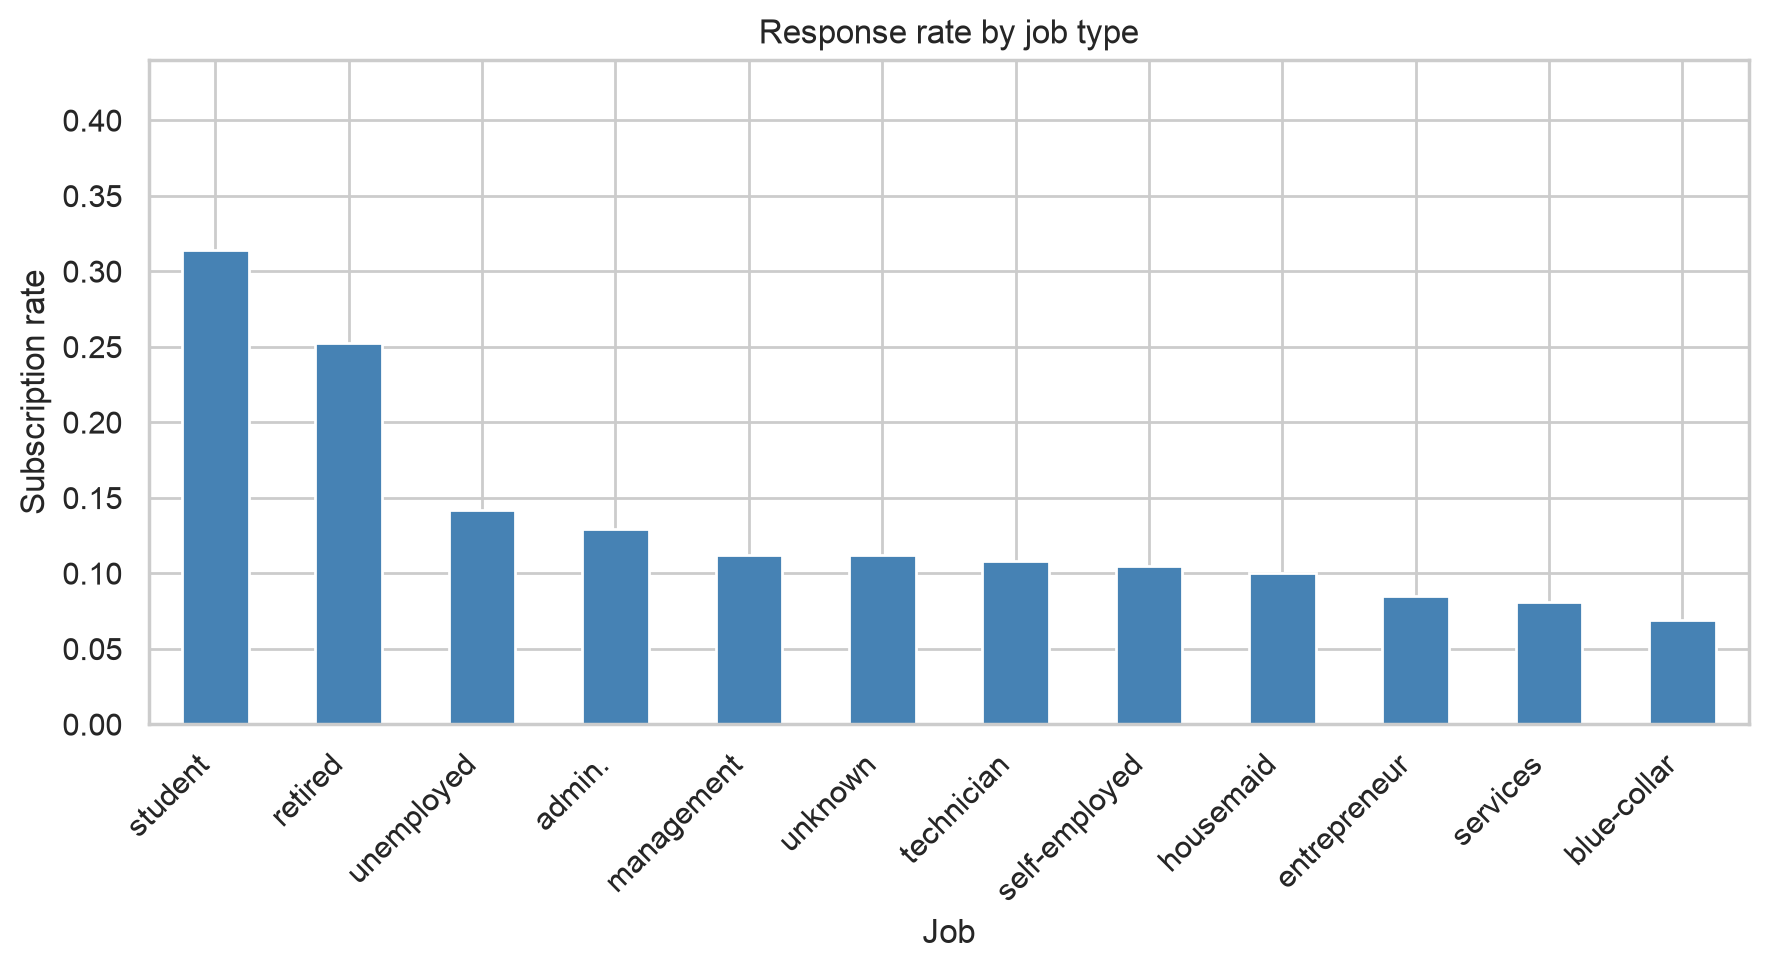

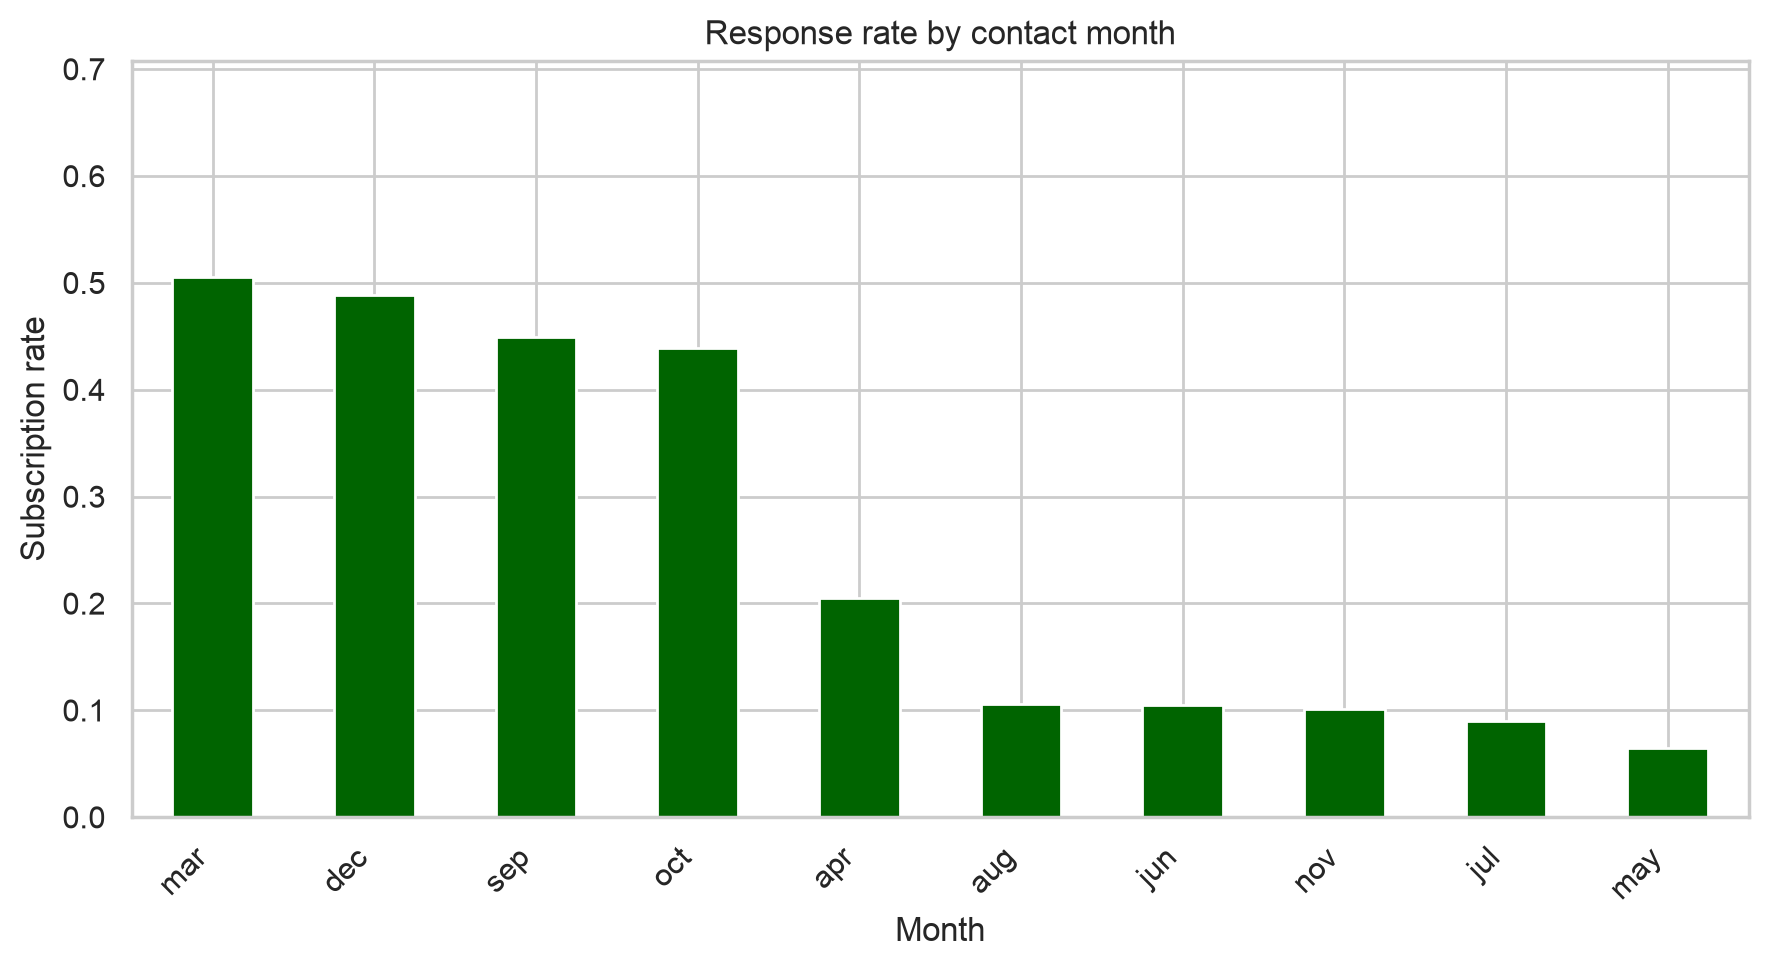

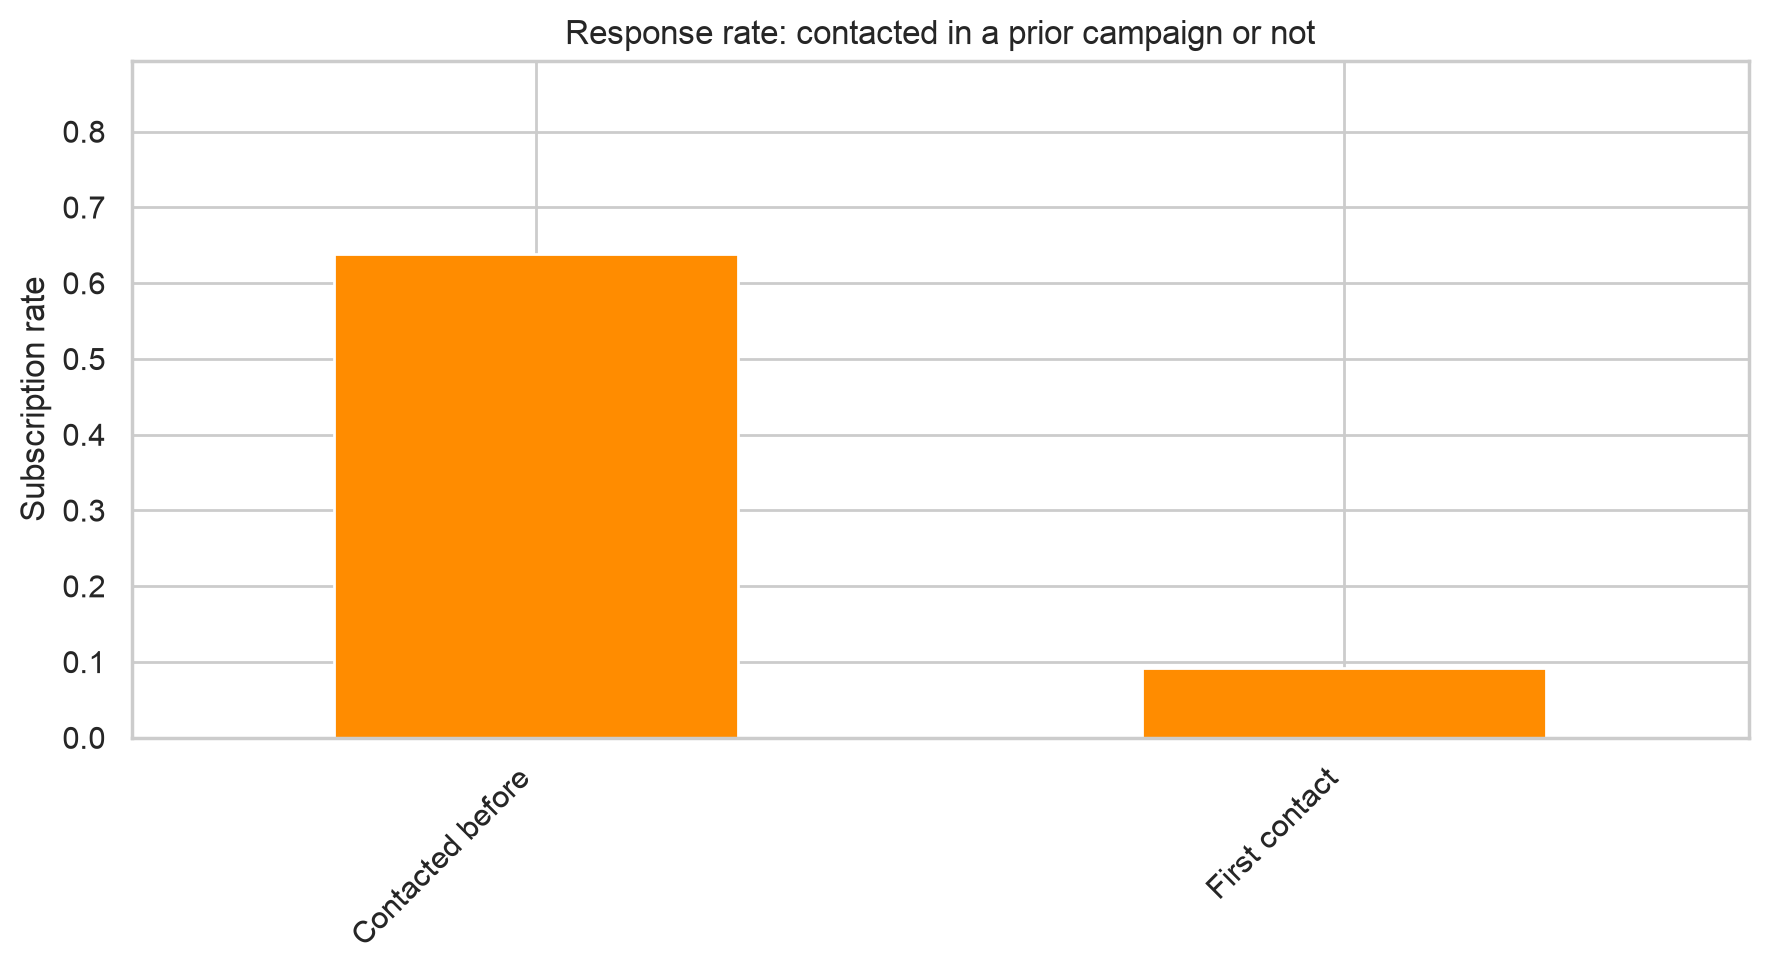

In [3]:
figure_paths = generate_eda_figures(raw_df)
from IPython.display import Image, display
for name in ['job_response', 'month_response', 'prior_contact_response']:
    if name in figure_paths:
        display(Image(figure_paths[name]))

In [4]:
print('Job response rates:')
for job, rate in summary['segment_response']['job'].items():
    print(f'  {job:15} {rate:.3f}')

Job response rates:
  student         0.314
  retired         0.252
  unemployed      0.142
  admin.          0.130
  management      0.112
  unknown         0.112
  technician      0.108
  self-employed   0.105
  housemaid       0.100
  entrepreneur    0.085
  services        0.081
  blue-collar     0.069


Students and retirees convert far above average (31% and 25%), while blue-collar and services workers convert below average (~7-8%). This likely reflects age and life-stage effects — students and retirees have more flexible time and different savings priorities —  rather than job title itself being causal.

## Response rate by contact month

In [5]:
print('Month response rates:')
for month, rate in sorted(summary['segment_response']['month'].items(), key=lambda kv: -kv[1]):
    print(f'  {month:6} {rate:.3f}')

Month response rates:
  mar    0.505
  dec    0.489
  sep    0.449
  oct    0.439
  apr    0.205
  aug    0.106
  jun    0.105
  nov    0.101
  jul    0.090
  may    0.064


March, September, October and December convert 4-5x higher than May-August. The next section shows this isn't seasonal customer mood — it tracks a macroeconomic shift across the data-collection period.

## Economic conditions and conversion

The five economic columns (`emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`) are national indicators for the time of contact, not facts about the customer. Because the file is contact-ordered, grouping by month roughly reconstructs the macro timeline:

In [6]:
econ_by_month = (raw_df.groupby('month')
                  .agg(customers=('y', 'size'),
                       conversion=('y', lambda s: (s == 'yes').mean()),
                       euribor3m=('euribor3m', 'median'),
                       nr_employed=('nr.employed', 'median'))
                  .sort_values('euribor3m'))
econ_by_month

,customers,conversion,euribor3m,nr_employed
month,,,,
dec,182,0.489011,0.7150,5023.5
oct,718,0.438719,0.7420,5017.5
sep,570,0.449123,0.8765,4963.6
apr,2632,0.204787,1.4050,5099.1
mar,546,0.505495,1.5100,5099.1
nov,4101,0.101439,4.1200,5195.8
may,13769,0.064347,4.8560,5191.0
jun,5318,0.105115,4.9590,5228.1
jul,7174,0.090466,4.9620,5228.1


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(econ_by_month['euribor3m'], econ_by_month['conversion'], s=econ_by_month['customers'] / 20, alpha=0.7)
for month, row in econ_by_month.iterrows():
    ax.annotate(month, (row['euribor3m'], row['conversion']), textcoords='offset points', xytext=(5, 3))
ax.set_xlabel('Median euribor3m (bubble size = customers contacted)')
ax.set_ylabel('Subscription rate')
ax.set_title('Lower interbank rates coincide with much higher conversion')
plt.show()

/var/folders/97/d0q84ynd0k5b2p19rklm8_800000gn/T/ipykernel_77410/712874059.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Median `euribor3m` by month correlates with conversion at **r = -0.91**: the four lowest-rate months (Dec/Oct/Sep at 0.7-0.9%, Mar at 1.5%) convert at 44-51%, while the four highest-rate months (May-Aug, 4.9-5.0%) convert at only 6-11% and account for most of the call volume. April and November sit in between on rate and roughly track it, though not perfectly — April's rate is nearly as low as March's but its conversion is only 21%, a reminder that this is a correlation between two things that both drifted over the same period, not a guarantee the relationship is linear or causal.

The practical consequence: **evaluating the model on a random 80/20 split mixes both economic regimes into both the train and test sets.** A deployed model will eventually operate in a regime it wasn't trained on — notebook 04 checks how much that costs with a purely time-based split instead.

## Contact type

In [8]:
print(summary['segment_response']['contact'])

{'cellular': 0.14737607099143207, 'telephone': 0.05231321457059293}


Cellular contacts convert roughly 3x better than landline (`telephone`), likely reflecting who still primarily used a landline in this period (older, potentially less digitally engaged customers) more than the channel itself.

## Key takeaways for modeling

- Prior contact history (`pdays`, `previous`, `poutcome`) is the single strongest legitimate signal — 6x lift.
- Job, month and contact type all carry real signal but overlap with age, economic regime, and contact-channel demographics respectively.
- Month and the economic indicators are highly correlated (both trace the same timeline), so a temporal validation check matters alongside the standard random split.
- `duration` remains excluded throughout.